### Data Retrieval

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
display(train_df.head())

def optimize_memory(df):
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = pd.to_numeric(df[col], downcast='float')
        if df[col].dtype == 'object':
            df[col] = df[col].astype('category')
    return df

train_df = optimize_memory(train_df)
test_df = optimize_memory(test_df)

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Data Cleaning

In [3]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
for col in none_cols:
    train_df[col] = train_df[col].cat.add_categories(['None']).fillna('None')

train_df = train_df[train_df['GrLivArea'] < 4000].reset_index(drop=True)

train_df['SalePrice'] = np.log1p(train_df['SalePrice'])

### Exploratory Data Analysis (EDA)

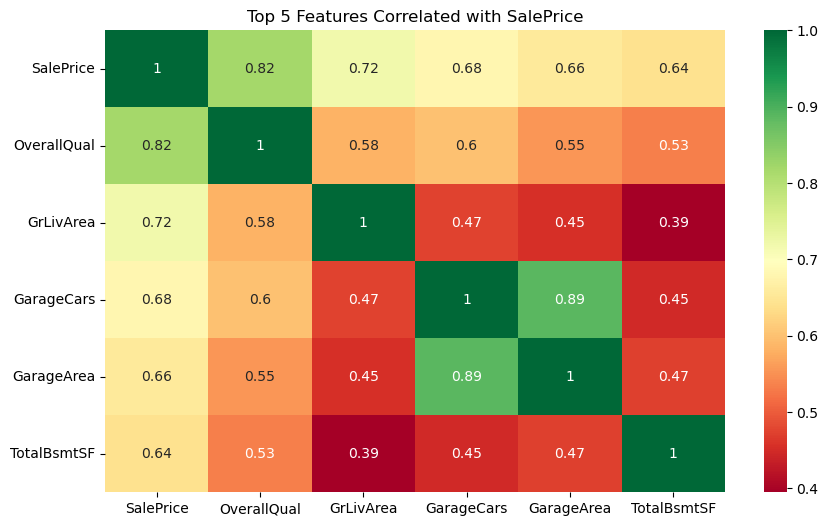

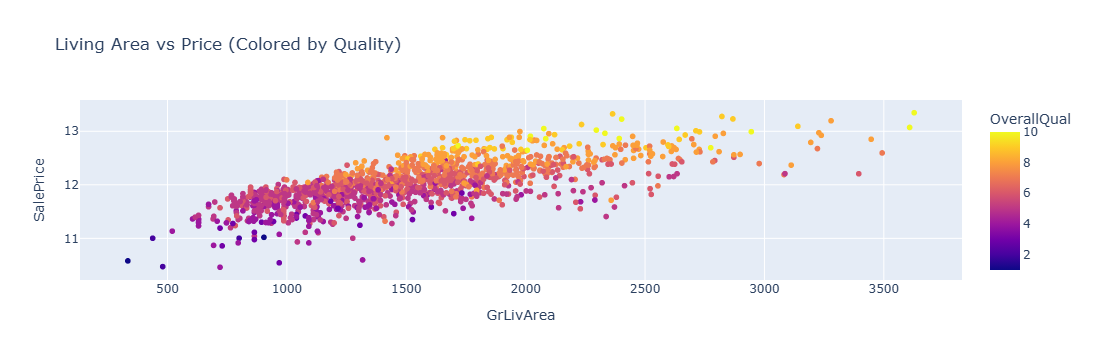

In [4]:
plt.figure(figsize=(10, 6))
top_corr = train_df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False).head(6)
sns.heatmap(train_df[top_corr.index].corr(), annot=True, cmap='RdYlGn')
plt.title("Top 5 Features Correlated with SalePrice")
plt.show()

fig = px.scatter(train_df, x="GrLivArea", y="SalePrice", color="OverallQual",
                 title="Living Area vs Price (Colored by Quality)")
fig.show()

### Feature Engineering

In [5]:
train_df['TotalSF'] = train_df['TotalBsmtSF'] + train_df['1stFlrSF'] + train_df['2ndFlrSF']

qual_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}
train_df['ExterQual'] = train_df['ExterQual'].map(qual_map)

train_df = pd.get_dummies(train_df, columns=['Neighborhood', 'BldgType'])